In [1]:
"""
Ensemble learning and hyper parameter tuning 

"""

'\nEnsemble learning and hyper parameter tuning \n\n'

In [2]:
import numpy as np
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics 

from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report,accuracy_score

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier


#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [3]:
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\DIABETECS'

In [4]:
df = pd.read_csv("Surgery_survival.csv")

In [5]:
df.head(3)

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   30      305 non-null    int64
 1   64      305 non-null    int64
 2   1       305 non-null    int64
 3   1.1     305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [7]:
df.rename(columns={"30":"age","64":"year","1":"nodes","1.1":"status"},inplace=True)

In [8]:
df.describe()

,age,year,nodes,status
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [9]:
print(df.isnull().sum())

age       0
year      0
nodes     0
status    0
dtype: int64


In [10]:
df["status"].value_counts()

1    224
2     81
Name: status, dtype: int64

In [11]:
df["status"]=df["status"].map({1:0,2:1})

In [12]:
df["status"].value_counts()

0    224
1     81
Name: status, dtype: int64

# EDA


In [13]:
#Correlation Analysis

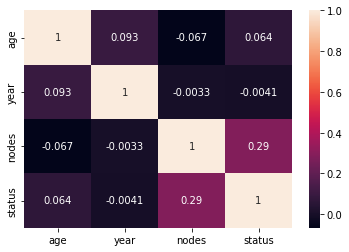

In [14]:
sns.heatmap(df.corr(), annot=True)
plt.show()

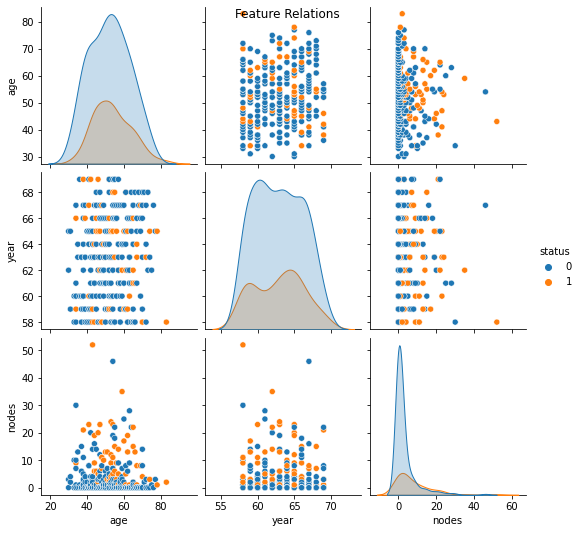

In [15]:
g1 = sns.pairplot(df, hue='status')
g1.fig.suptitle('Feature Relations')
plt.show()

In [16]:
df.head()

,age,year,nodes,status
0,30,62,3,0
1,30,65,0,0
2,31,59,2,0
3,31,65,4,0
4,33,58,10,0


In [17]:
#Data Split

In [18]:
y = df['status']
X = df.drop(['status'], axis=1)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [20]:
#Data Scaling
"""
We will scale the features in our subsets, 
in order to use them to train, validate, and test models 
that will benefit from feature scaling.
"""

'\nWe will scale the features in our subsets, \nin order to use them to train, validate, and test models \nthat will benefit from feature scaling.\n'

In [21]:
sc_X = StandardScaler()

Xsc_train = sc_X.fit_transform(X_train)
Xsc_test = sc_X.fit_transform(X_test)

# Model Building

# Naive Bayes

In [22]:
"""
Gaussian Naive Bayes classifier, It is non Parametric Algorithm .
work good in both condition when features are normally distributed,  features don't 
follow a normal distribution.
"""

"\nGaussian Naive Bayes classifier, It is non Parametric Algorithm .\nwork good in both condition when features are normally distributed,  features don't \nfollow a normal distribution.\n"

In [23]:
nbm = GaussianNB()
nbm.fit(Xsc_train,y_train)
nbm_pred = nbm.predict(Xsc_test)

print('Gaussian Naive Bayes Performance:')
print('---------------------------------')
print('Accuracy        : ', accuracy_score(y_test, nbm_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, nbm_pred))
print("classification report:\n: ",classification_report(y_test, nbm_pred))

Gaussian Naive Bayes Performance:
---------------------------------
Accuracy        :  0.7934782608695652
Confusion Matrix:
  [[68  6]
 [13  5]]
classification report:
:                precision    recall  f1-score   support

           0       0.84      0.92      0.88        74
           1       0.45      0.28      0.34        18

    accuracy                           0.79        92
   macro avg       0.65      0.60      0.61        92
weighted avg       0.76      0.79      0.77        92



# KNN

In [24]:
"""
KNN
For K-Nearest Neighbor classifier, we will be using the scaled version of our dataset.

KNN is a non-parametric (no assumption for underlying data distribution) 
learning algorithm, the model structure determined from the dataset. 
This will be very helpful in dataset where many features do not follow a 
specific theoretical assumption.
"""

'\nKNN\nFor K-Nearest Neighbor classifier, we will be using the scaled version of our dataset.\n\nKNN is a non-parametric (no assumption for underlying data distribution) \nlearning algorithm, the model structure determined from the dataset. \nThis will be very helpful in dataset where many features do not follow a \nspecific theoretical assumption.\n'

In [25]:
knn = KNeighborsClassifier(n_neighbors=5,weights='uniform',leaf_size=30,p=2) #default values
knn.fit(Xsc_train,y_train)
knn_pred = knn.predict(Xsc_test)


In [26]:
print('K-Nearest Neighbor Initial Performance:')
print('---------------------------------------')
print('Accuracy        : ', accuracy_score(y_test, knn_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, knn_pred))
print("classification report:\n: ",classification_report(y_test, knn_pred))

K-Nearest Neighbor Initial Performance:
---------------------------------------
Accuracy        :  0.7934782608695652
Confusion Matrix:
  [[65  9]
 [10  8]]
classification report:
:                precision    recall  f1-score   support

           0       0.87      0.88      0.87        74
           1       0.47      0.44      0.46        18

    accuracy                           0.79        92
   macro avg       0.67      0.66      0.66        92
weighted avg       0.79      0.79      0.79        92



In [27]:
"""
Compared to Naive Bayes, KNN's initial model causes a considerable
increase in accuracy and F1 score, with a decrease in recall. 
Now we will try increase its performance even more with hyper-parameter 
tuning via grid search.
"""

"\nCompared to Naive Bayes, KNN's initial model causes a considerable\nincrease in accuracy and F1 score, with a decrease in recall. \nNow we will try increase its performance even more with hyper-parameter \ntuning via grid search.\n"

# KNN Tuning


In [28]:
"""
The following KNN parameters will be tuned:

leaf_size: Leaf size can affect the speed and the memory 
required to store the tree.
n_neighbors: Number of neighbors to use
p: determines the distance metric to be 
used: p=1 ==> manhattan_distance, and p=2 ==> euclidean_distance
weights: weight function used in prediction
"""

'\nThe following KNN parameters will be tuned:\n\nleaf_size: Leaf size can affect the speed and the memory \nrequired to store the tree.\nn_neighbors: Number of neighbors to use\np: determines the distance metric to be \nused: p=1 ==> manhattan_distance, and p=2 ==> euclidean_distance\nweights: weight function used in prediction\n'

In [74]:
knn_param_grid = {'n_neighbors': list(range(1,50)), 
                  'leaf_size': [1,10,20,30,40,50,100], 
                  'p': [1,2],
                  'weights': ['uniform','distance']}

knn_rand = RandomizedSearchCV(KNeighborsClassifier(),
                        knn_param_grid,
                        verbose=3)

from sklearn.model_selection import GridSearchCV
knn_grid1 = GridSearchCV(KNeighborsClassifier(),
                        knn_param_grid,
                        verbose=3)

In [75]:
knn_grid1.fit(Xsc_train,y_train)

Fitting 5 folds for each of 1372 candidates, totalling 6860 fits
[CV 1/5] END leaf_size=1, n_neighbors=1, p=1, weights=uniform;, score=0.628 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=1, p=1, weights=uniform;, score=0.581 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=1, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=1, p=1, weights=uniform;, score=0.429 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=1, p=1, weights=uniform;, score=0.595 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=1, p=1, weights=distance;, score=0.628 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=1, p=1, weights=distance;, score=0.581 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=1, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=1, p=1, weights=distance;, score=0.429 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=1, p=1, weights=distance;, score=0.595

[CV 1/5] END leaf_size=1, n_neighbors=6, p=1, weights=distance;, score=0.744 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=6, p=1, weights=distance;, score=0.605 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=6, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=6, p=1, weights=distance;, score=0.619 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=6, p=1, weights=distance;, score=0.619 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=6, p=2, weights=uniform;, score=0.767 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=6, p=2, weights=uniform;, score=0.651 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=6, p=2, weights=uniform;, score=0.744 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=6, p=2, weights=uniform;, score=0.762 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=6, p=2, weights=uniform;, score=0.595 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=6, p=2,

[CV 4/5] END leaf_size=1, n_neighbors=11, p=2, weights=distance;, score=0.690 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=11, p=2, weights=distance;, score=0.690 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=12, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=12, p=1, weights=uniform;, score=0.674 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=12, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=12, p=1, weights=uniform;, score=0.714 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=12, p=1, weights=uniform;, score=0.738 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=12, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=12, p=1, weights=distance;, score=0.605 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=12, p=1, weights=distance;, score=0.744 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbo

[CV 2/5] END leaf_size=1, n_neighbors=16, p=2, weights=uniform;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=16, p=2, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=16, p=2, weights=uniform;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=16, p=2, weights=uniform;, score=0.714 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=16, p=2, weights=distance;, score=0.744 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=16, p=2, weights=distance;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=16, p=2, weights=distance;, score=0.698 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=16, p=2, weights=distance;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=16, p=2, weights=distance;, score=0.714 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=17, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbo

[CV 3/5] END leaf_size=1, n_neighbors=21, p=1, weights=uniform;, score=0.744 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=21, p=1, weights=uniform;, score=0.714 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=21, p=1, weights=uniform;, score=0.690 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=21, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=21, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbors=21, p=1, weights=distance;, score=0.744 total time=   0.0s
[CV 4/5] END leaf_size=1, n_neighbors=21, p=1, weights=distance;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=1, n_neighbors=21, p=1, weights=distance;, score=0.714 total time=   0.0s
[CV 1/5] END leaf_size=1, n_neighbors=21, p=2, weights=uniform;, score=0.744 total time=   0.0s
[CV 2/5] END leaf_size=1, n_neighbors=21, p=2, weights=uniform;, score=0.721 total time=   0.0s
[CV 3/5] END leaf_size=1, n_neighbo

...

[CV 5/5] END leaf_size=100, n_neighbors=32, p=2, weights=uniform;, score=0.738 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=32, p=2, weights=distance;, score=0.744 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=32, p=2, weights=distance;, score=0.721 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=32, p=2, weights=distance;, score=0.674 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=32, p=2, weights=distance;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=32, p=2, weights=distance;, score=0.738 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=33, p=1, weights=uniform;, score=0.698 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=33, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=33, p=1, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=33, p=1, weights=uniform;, score=0.690 total time=   0.0s
[CV 5/5] END le

[CV 1/5] END leaf_size=100, n_neighbors=37, p=1, weights=distance;, score=0.698 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=37, p=1, weights=distance;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=37, p=1, weights=distance;, score=0.674 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=37, p=1, weights=distance;, score=0.667 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=37, p=1, weights=distance;, score=0.762 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=37, p=2, weights=uniform;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=37, p=2, weights=uniform;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=37, p=2, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=37, p=2, weights=uniform;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=37, p=2, weights=uniform;, score=0.738 total time=   0.0s
[CV 1/5] END le

[CV 1/5] END leaf_size=100, n_neighbors=41, p=2, weights=distance;, score=0.698 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=41, p=2, weights=distance;, score=0.674 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=41, p=2, weights=distance;, score=0.674 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=41, p=2, weights=distance;, score=0.714 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=41, p=2, weights=distance;, score=0.762 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=42, p=1, weights=uniform;, score=0.698 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=42, p=1, weights=uniform;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=42, p=1, weights=uniform;, score=0.698 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=42, p=1, weights=uniform;, score=0.714 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=42, p=1, weights=uniform;, score=0.738 total time=   0.0s
[CV 1/5] END le

[CV 4/5] END leaf_size=100, n_neighbors=46, p=1, weights=distance;, score=0.690 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=46, p=1, weights=distance;, score=0.762 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=46, p=2, weights=uniform;, score=0.698 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=46, p=2, weights=uniform;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=46, p=2, weights=uniform;, score=0.721 total time=   0.0s
[CV 4/5] END leaf_size=100, n_neighbors=46, p=2, weights=uniform;, score=0.690 total time=   0.0s
[CV 5/5] END leaf_size=100, n_neighbors=46, p=2, weights=uniform;, score=0.738 total time=   0.0s
[CV 1/5] END leaf_size=100, n_neighbors=46, p=2, weights=distance;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=100, n_neighbors=46, p=2, weights=distance;, score=0.698 total time=   0.0s
[CV 3/5] END leaf_size=100, n_neighbors=46, p=2, weights=distance;, score=0.674 total time=   0.0s
[CV 4/5] END le

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': [1, 10, 20, 30, 40, 50, 100],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30, ...],
                         'p': [1, 2], 'weights': ['uniform', 'distance']},
             verbose=3)

In [73]:
knn_rand.fit(Xsc_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END leaf_size=20, n_neighbors=36, p=2, weights=distance;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=20, n_neighbors=36, p=2, weights=distance;, score=0.721 total time=   0.0s
[CV 3/5] END leaf_size=20, n_neighbors=36, p=2, weights=distance;, score=0.674 total time=   0.0s
[CV 4/5] END leaf_size=20, n_neighbors=36, p=2, weights=distance;, score=0.738 total time=   0.0s
[CV 5/5] END leaf_size=20, n_neighbors=36, p=2, weights=distance;, score=0.738 total time=   0.0s
[CV 1/5] END leaf_size=10, n_neighbors=4, p=1, weights=distance;, score=0.721 total time=   0.0s
[CV 2/5] END leaf_size=10, n_neighbors=4, p=1, weights=distance;, score=0.581 total time=   0.0s
[CV 3/5] END leaf_size=10, n_neighbors=4, p=1, weights=distance;, score=0.744 total time=   0.0s
[CV 4/5] END leaf_size=10, n_neighbors=4, p=1, weights=distance;, score=0.524 total time=   0.0s
[CV 5/5] END leaf_size=10, n_neighbors=4, p=1, weights=distan

RandomizedSearchCV(estimator=KNeighborsClassifier(),
                   param_distributions={'leaf_size': [1, 10, 20, 30, 40, 50,
                                                      100],
                                        'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10, 11, 12, 13, 14,
                                                        15, 16, 17, 18, 19, 20,
                                                        21, 22, 23, 24, 25, 26,
                                                        27, 28, 29, 30, ...],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   verbose=3)

In [31]:
#  best parameter combination as per Random search CV
knn_rand.best_params_

{'weights': 'uniform', 'p': 2, 'n_neighbors': 16, 'leaf_size': 30}

In [76]:
# best parameter combination as per grid search cv
knn_grid1.best_params_

{'leaf_size': 1, 'n_neighbors': 24, 'p': 2, 'weights': 'uniform'}

In [78]:
knn_rand.best_estimator_

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_estimator_'

In [79]:
knn_grid1.best_estimator_

KNeighborsClassifier(leaf_size=1, n_neighbors=24)

In [33]:
knn_rand_pred = knn_rand.predict(Xsc_test)

In [34]:
print('K-Nearest Neighbor Tuned Performance:')
print('-------------------------------------')
print('Accuracy        : ', accuracy_score(y_test, knn_rand_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, knn_rand_pred))
print("classification report:\n: ",classification_report(y_test, knn_rand_pred))

K-Nearest Neighbor Tuned Performance:
-------------------------------------
Accuracy        :  0.7934782608695652
Confusion Matrix:
  [[68  6]
 [13  5]]
classification report:
:                precision    recall  f1-score   support

           0       0.84      0.92      0.88        74
           1       0.45      0.28      0.34        18

    accuracy                           0.79        92
   macro avg       0.65      0.60      0.61        92
weighted avg       0.76      0.79      0.77        92



# SVM

In [35]:
"""SVM
For SVM classifier, we will be using the scaled version of our dataset.

SVM offers high accuracy classification, and it is known for its kernel 
trick to handle nonlinear input spaces. The classifier separates data points 
using a hyperplane with the largest amount of margin. SVM finds an optimal 
hyperplane which helps in classifying new data points.
"""

'SVM\nFor SVM classifier, we will be using the scaled version of our dataset.\n\nSVM offers high accuracy classification, and it is known for its kernel \ntrick to handle nonlinear input spaces. The classifier separates data points \nusing a hyperplane with the largest amount of margin. SVM finds an optimal \nhyperplane which helps in classifying new data points.\n'

In [80]:
svm = SVC(kernel='linear')
svm.fit(Xsc_train,y_train)

svm_pred = svm.predict(Xsc_test)



In [81]:
print('SVM Initial Performance:')
print('------------------------')
print('Accuracy        : ', accuracy_score(y_test, svm_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, svm_pred))
print("classification report:\n: ",classification_report(y_test, svm_pred))

SVM Initial Performance:
------------------------
Accuracy        :  0.8043478260869565
Confusion Matrix:
  [[71  3]
 [15  3]]
classification report:
:                precision    recall  f1-score   support

           0       0.83      0.96      0.89        74
           1       0.50      0.17      0.25        18

    accuracy                           0.80        92
   macro avg       0.66      0.56      0.57        92
weighted avg       0.76      0.80      0.76        92



In [38]:
"""
Compared to KNN, SVM's initial model resulted in a considerable 
increase in all performance metrics. Now we will try increase
its performance even more with hyper-parameter tuning via grid search.
"""

"\nCompared to KNN, SVM's initial model resulted in a considerable \nincrease in all performance metrics. Now we will try increase\nits performance even more with hyper-parameter tuning via grid search.\n"

# SVM Tuning

In [39]:
"""
SVM Tuning
The following parameters will be tuned:

Kernel: Transforms the given dataset into the required form. 
There are various types of functions such as linear, polynomial, 
and radial basis function (RBF). Polynomial and RBF are useful 
for non-linear hyperplane. This transformation can lead to more 
accurate classifiers.
Regularization: C parameter used to maintain regularization. 
A smaller value of C creates a small-margin hyperplane and a 
larger value of C creates a larger-margin hyperplane.
Gamma: A lower value of Gamma will loosely fit the training 
dataset, whereas a higher value of gamma will exactly fit the 
training dataset, which causes over-fitting. A low value of 
gamma considers only nearby points in calculating the separation line, 
while a large value of gamma considers all the data points in the 
calculation of the separation line.
"""

'\nSVM Tuning\nThe following parameters will be tuned:\n\nKernel: Transforms the given dataset into the required form. \nThere are various types of functions such as linear, polynomial, \nand radial basis function (RBF). Polynomial and RBF are useful \nfor non-linear hyperplane. This transformation can lead to more \naccurate classifiers.\nRegularization: C parameter used to maintain regularization. \nA smaller value of C creates a small-margin hyperplane and a \nlarger value of C creates a larger-margin hyperplane.\nGamma: A lower value of Gamma will loosely fit the training \ndataset, whereas a higher value of gamma will exactly fit the \ntraining dataset, which causes over-fitting. A low value of \ngamma considers only nearby points in calculating the separation line, \nwhile a large value of gamma considers all the data points in the \ncalculation of the separation line.\n'

In [40]:
svm_param_rand = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [0.1,0.01,0.001,0.0001], 
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid']} 

svm_rand = RandomizedSearchCV(SVC(),
                        svm_param_rand,
                        refit=True,
                        verbose=3)


In [41]:
svm_rand.fit(Xsc_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END .C=1000, gamma=0.0001, kernel=poly;, score=0.698 total time=   0.0s
[CV 2/5] END .C=1000, gamma=0.0001, kernel=poly;, score=0.698 total time=   0.0s
[CV 3/5] END .C=1000, gamma=0.0001, kernel=poly;, score=0.698 total time=   0.0s
[CV 4/5] END .C=1000, gamma=0.0001, kernel=poly;, score=0.714 total time=   0.0s
[CV 5/5] END .C=1000, gamma=0.0001, kernel=poly;, score=0.714 total time=   0.0s
[CV 1/5] END C=1000, gamma=0.001, kernel=linear;, score=0.698 total time=   1.7s
[CV 2/5] END C=1000, gamma=0.001, kernel=linear;, score=0.721 total time=   0.4s
[CV 3/5] END C=1000, gamma=0.001, kernel=linear;, score=0.721 total time=   1.5s
[CV 4/5] END C=1000, gamma=0.001, kernel=linear;, score=0.738 total time=   0.2s
[CV 5/5] END C=1000, gamma=0.001, kernel=linear;, score=0.738 total time=   0.1s
[CV 1/5] END C=0.1, gamma=0.0001, kernel=sigmoid;, score=0.698 total time=   0.0s
[CV 2/5] END C=0.1, gamma=0.0001, kernel=sigmoi

RandomizedSearchCV(estimator=SVC(),
                   param_distributions={'C': [0.1, 1, 10, 100, 1000],
                                        'gamma': [0.1, 0.01, 0.001, 0.0001],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   verbose=3)

In [42]:
svm_rand.best_params_

{'kernel': 'linear', 'gamma': 0.001, 'C': 1000}

In [43]:
svm_rand.best_estimator_

SVC(C=1000, gamma=0.001, kernel='linear')

In [44]:
svm_rand = SVC(C=10,kernel='rbf',degree=3,gamma=0.01) #default values
svm_rand.fit(Xsc_train,y_train)

svm_rand_pred = svm_rand.predict(Xsc_test)

print('SVM Tuned Performance:')
print('----------------------')
print('Accuracy        : ', accuracy_score(y_test, svm_rand_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, svm_rand_pred))
print("classification report:\n: ",classification_report(y_test, svm_rand_pred))

SVM Tuned Performance:
----------------------
Accuracy        :  0.8043478260869565
Confusion Matrix:
  [[71  3]
 [15  3]]
classification report:
:                precision    recall  f1-score   support

           0       0.83      0.96      0.89        74
           1       0.50      0.17      0.25        18

    accuracy                           0.80        92
   macro avg       0.66      0.56      0.57        92
weighted avg       0.76      0.80      0.76        92



# Logistic Regression

In [45]:
"""
Logistic Regression
Logistic regression measures the relationship between the 
categorical dependent variable and the independent variables 
by estimating probabilities using a logistic/sigmoid function.
"""

'\nLogistic Regression\nLogistic regression measures the relationship between the \ncategorical dependent variable and the independent variables \nby estimating probabilities using a logistic/sigmoid function.\n'

In [46]:
lrm = LogisticRegression(C=1.0,solver='lbfgs',) #default parameters
lrm.fit(X_train,y_train)
lrm_pred = lrm.predict(X_test)

print('Logistic Regression initial Performance:')
print('----------------------------------------')
print('Accuracy        : ', accuracy_score(y_test, lrm_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, lrm_pred))
print("classification report:\n: ",classification_report(y_test, lrm_pred))

Logistic Regression initial Performance:
----------------------------------------
Accuracy        :  0.8043478260869565
Confusion Matrix:
  [[71  3]
 [15  3]]
classification report:
:                precision    recall  f1-score   support

           0       0.83      0.96      0.89        74
           1       0.50      0.17      0.25        18

    accuracy                           0.80        92
   macro avg       0.66      0.56      0.57        92
weighted avg       0.76      0.80      0.76        92



# Logistic Regression Tuning

In [47]:
lrm_param_rand = {'C': [0.01, 0.1, 1, 10, 100],  
              'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']} 
lrm_grid = RandomizedSearchCV(LogisticRegression(),
                        lrm_param_rand,
                        refit=True,
                        verbose=3)

In [48]:
lrm_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ................C=0.1, solver=saga;, score=0.721 total time=   0.0s
[CV 2/5] END ................C=0.1, solver=saga;, score=0.721 total time=   0.0s
[CV 3/5] END ................C=0.1, solver=saga;, score=0.698 total time=   0.0s
[CV 4/5] END ................C=0.1, solver=saga;, score=0.738 total time=   0.0s
[CV 5/5] END ................C=0.1, solver=saga;, score=0.738 total time=   0.0s
[CV 1/5] END ............C=10, solver=newton-cg;, score=0.721 total time=   0.0s
[CV 2/5] END ............C=10, solver=newton-cg;, score=0.721 total time=   0.0s
[CV 3/5] END ............C=10, solver=newton-cg;, score=0.698 total time=   0.0s
[CV 4/5] END ............C=10, solver=newton-cg;, score=0.738 total time=   0.0s
[CV 5/5] END ............C=10, solver=newton-cg;, score=0.738 total time=   0.0s
[CV 1/5] END .................C=10, solver=saga;, score=0.721 total time=   0.0s
[CV 2/5] END .................C=10, solver=saga;

RandomizedSearchCV(estimator=LogisticRegression(),
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'solver': ['newton-cg', 'lbfgs', 'sag',
                                                   'saga']},
                   verbose=3)

In [49]:
lrm_grid.best_params_

{'solver': 'saga', 'C': 0.1}

In [50]:
lrm_grid.best_estimator_

LogisticRegression(C=0.1, solver='saga')

In [51]:
lrm_grid.fit(X_train,y_train)
lrm_grid_pred = lrm_grid.predict(X_test)

print('Logistic Regression Tuned Performance:')
print('--------------------------------------')
print('Accuracy        : ', accuracy_score(y_test, lrm_grid_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, lrm_grid_pred))
print("classification report:\n: ",classification_report(y_test, lrm_grid_pred))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...........C=0.1, solver=newton-cg;, score=0.721 total time=   0.0s
[CV 2/5] END ...........C=0.1, solver=newton-cg;, score=0.721 total time=   0.0s
[CV 3/5] END ...........C=0.1, solver=newton-cg;, score=0.698 total time=   0.0s
[CV 4/5] END ...........C=0.1, solver=newton-cg;, score=0.738 total time=   0.0s
[CV 5/5] END ...........C=0.1, solver=newton-cg;, score=0.738 total time=   0.0s
[CV 1/5] END ................C=10, solver=lbfgs;, score=0.721 total time=   0.0s
[CV 2/5] END ................C=10, solver=lbfgs;, score=0.721 total time=   0.0s
[CV 3/5] END ................C=10, solver=lbfgs;, score=0.698 total time=   0.0s
[CV 4/5] END ................C=10, solver=lbfgs;, score=0.738 total time=   0.0s
[CV 5/5] END ................C=10, solver=lbfgs;, score=0.738 total time=   0.0s
[CV 1/5] END ...............C=0.1, solver=lbfgs;, score=0.721 total time=   0.0s
[CV 2/5] END ...............C=0.1, solver=lbfgs;

# Random Forest

In [52]:
"""
Random Forest
A random forest is a meta estimator that fits a number of decision tree 
classifiers on various sub-samples of the dataset and uses averaging
to improve the predictive accuracy and control over-fitting. 
The sub-sample size is controlled with the max_samples parameter
if bootstrap=True (default), otherwise the whole dataset is used to build each tree.
"""

'\nRandom Forest\nA random forest is a meta estimator that fits a number of decision tree \nclassifiers on various sub-samples of the dataset and uses averaging\nto improve the predictive accuracy and control over-fitting. \nThe sub-sample size is controlled with the max_samples parameter\nif bootstrap=True (default), otherwise the whole dataset is used to build each tree.\n'

In [53]:
rfm = RandomForestClassifier(n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='auto',
    bootstrap=True) #default parameters
rfm.fit(X_train,y_train)
rfm_pred = rfm.predict(X_test)

print('Random Forest initial Performance:')
print('----------------------------------')
print('Accuracy        : ', accuracy_score(y_test, rfm_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, rfm_pred))
print("classification report:\n: ",classification_report(y_test, rfm_pred))

C:\Users\User\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py:425: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Random Forest initial Performance:
----------------------------------
Accuracy        :  0.782608695652174
Confusion Matrix:
  [[65  9]
 [11  7]]
classification report:
:                precision    recall  f1-score   support

           0       0.86      0.88      0.87        74
           1       0.44      0.39      0.41        18

    accuracy                           0.78        92
   macro avg       0.65      0.63      0.64        92
weighted avg       0.77      0.78      0.78        92



# Random Forest Tuning

In [54]:
"""
Random Forest Tuning
Scikit-Learn documentation tells us the most important settings
are the number of trees in the forest (n_estimators) and the 
number of features considered for splitting at each leaf node 
(max_features). We will try adjusting the following set of hyperparameters:

n_estimators = number of trees in the foreset
max_features = max number of features considered for splitting a node
max_depth = max number of levels in each decision tree
min_samples_split = min number of data points placed in a node before the node is split
min_samples_leaf = min number of data points allowed in a leaf node
Due to the large number of parameters and parameter values to be tested, 
we will use random search this time.
"""

'\nRandom Forest Tuning\nScikit-Learn documentation tells us the most important settings\nare the number of trees in the forest (n_estimators) and the \nnumber of features considered for splitting at each leaf node \n(max_features). We will try adjusting the following set of hyperparameters:\n\nn_estimators = number of trees in the foreset\nmax_features = max number of features considered for splitting a node\nmax_depth = max number of levels in each decision tree\nmin_samples_split = min number of data points placed in a node before the node is split\nmin_samples_leaf = min number of data points allowed in a leaf node\nDue to the large number of parameters and parameter values to be tested, \nwe will use random search this time.\n'

In [55]:
rfm_param_grid = {'n_estimators': [10,80,200,800,2000,5000], 
                  'max_features': ['sqrt', 'log2'],
                  'max_depth': [10,20,30,40,50,100],
                  'min_samples_split': [2,5,10,20],
                  'min_samples_leaf': [1,2,7,15]} 

rfm_grid = RandomizedSearchCV(RandomForestClassifier(),
                        rfm_param_grid,
                        n_iter=40,
                        n_jobs= -1)

In [56]:
rfm_grid.fit(X_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=40, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 100],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 7, 15],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [10, 80, 200, 800, 2000,
                                                         5000]})

In [57]:
rfm_grid_pred = rfm_grid.predict(X_test)

print('Random Forest Tuned Performance:')
print('--------------------------------')
print('----------------------------------')
print('Accuracy        : ', accuracy_score(y_test, rfm_grid_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, rfm_grid_pred))
print("classification report:\n: ",classification_report(y_test, rfm_grid_pred))

Random Forest Tuned Performance:
--------------------------------
----------------------------------
Accuracy        :  0.8152173913043478
Confusion Matrix:
  [[69  5]
 [12  6]]
classification report:
:                precision    recall  f1-score   support

           0       0.85      0.93      0.89        74
           1       0.55      0.33      0.41        18

    accuracy                           0.82        92
   macro avg       0.70      0.63      0.65        92
weighted avg       0.79      0.82      0.80        92



In [58]:
rfm_grid.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 7,
 'max_features': 'log2',
 'max_depth': 30}

In [59]:

rfm_grid.best_estimator_

RandomForestClassifier(max_depth=30, max_features='log2', min_samples_leaf=7,
                       n_estimators=200)

# Gradient Boost

In [61]:
"""
Gradient Boost
Gradient Boosted Regression Trees is basically a generalization 
of boosting to arbitrary differentiable loss functions. 
It produces a prediction model in the form of an ensemble 
of weak prediction models. Their main advantage lies in the
fact that they naturally handle the mixed type data.
"""

'\nGradient Boost\nGradient Boosted Regression Trees is basically a generalization \nof boosting to arbitrary differentiable loss functions. \nIt produces a prediction model in the form of an ensemble \nof weak prediction models. Their main advantage lies in the\nfact that they naturally handle the mixed type data.\n'

In [62]:
gbm = GradientBoostingClassifier(loss='deviance',
    learning_rate=0.1,
    n_estimators=100,
    subsample=1.0,
    criterion='friedman_mse',
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=3,
    max_features=None) #default parameters
gbm.fit(X_train,y_train)
gbm_pred = gbm.predict(X_test)

print('Gradient Boost initial Performance:')
print('-----------------------------------')
print('Accuracy        : ', accuracy_score(y_test, gbm_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, gbm_pred))
print("classification report:\n: ",classification_report(y_test, gbm_pred))

Gradient Boost initial Performance:
-----------------------------------
Accuracy        :  0.7934782608695652
Confusion Matrix:
  [[67  7]
 [12  6]]
classification report:
:                precision    recall  f1-score   support

           0       0.85      0.91      0.88        74
           1       0.46      0.33      0.39        18

    accuracy                           0.79        92
   macro avg       0.65      0.62      0.63        92
weighted avg       0.77      0.79      0.78        92



C:\Users\User\anaconda3\lib\site-packages\sklearn\ensemble\_gb.py:280: FutureWarning: The loss parameter name 'deviance' was deprecated in v1.1 and will be removed in version 1.3. Use the new parameter name 'log_loss' which is equivalent.
  warnings.warn(


In [63]:
"""
Gradient Boost Tuning
We will try adjusting the following set of hyperparameters:

n_estimators = number of trees in the forest
loss = loss function to be optimized
learning_rate = shrinks the contribution of each classifier
subsample = The fraction of samples to be used for fitting the individual base learners
max_features = max number of features considered for splitting a node
max_depth = max number of levels in each decision tree
min_samples_split = min number of data points placed in a node before the node is split
min_samples_leaf = min number of data points allowed in a leaf node
"""

'\nGradient Boost Tuning\nWe will try adjusting the following set of hyperparameters:\n\nn_estimators = number of trees in the forest\nloss = loss function to be optimized\nlearning_rate = shrinks the contribution of each classifier\nsubsample = The fraction of samples to be used for fitting the individual base learners\nmax_features = max number of features considered for splitting a node\nmax_depth = max number of levels in each decision tree\nmin_samples_split = min number of data points placed in a node before the node is split\nmin_samples_leaf = min number of data points allowed in a leaf node\n'

In [64]:
"""
Due to the large number of parameters and parameter values 
to be tested, we will use random search .
"""

'\nDue to the large number of parameters and parameter values \nto be tested, we will use random search .\n'

In [65]:
gbm_param_grid = {'n_estimators': [10,80,200,800,2000,5000], 
                  'max_features': ['sqrt', 'log2'],
                  'max_depth': [10,20,30,40,50,100],
                  'min_samples_split': [2,5,10,20],
                  'min_samples_leaf': [1,2,7,15],
                  'loss': ['deviance', 'exponential'],
                  'learning_rate':[0.01,0.1,0.5],
                  'subsample':[0.7, 0.8,0.9, 1]} 

gbm_grid = RandomizedSearchCV(GradientBoostingClassifier(),
                        gbm_param_grid,
                        n_iter=40,
                        n_jobs= -1)

In [66]:
gbm_grid.fit(X_train, y_train)

RandomizedSearchCV(estimator=GradientBoostingClassifier(), n_iter=40, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['deviance', 'exponential'],
                                        'max_depth': [10, 20, 30, 40, 50, 100],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 7, 15],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [10, 80, 200, 800, 2000,
                                                         5000],
                                        'subsample': [0.7, 0.8, 0.9, 1]})

In [67]:
gbm_grid.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_samples_split': 20,
 'min_samples_leaf': 7,
 'max_features': 'log2',
 'max_depth': 40,
 'loss': 'exponential',
 'learning_rate': 0.01}

In [68]:
gbm_grid.best_estimator_

GradientBoostingClassifier(learning_rate=0.01, loss='exponential', max_depth=40,
                           max_features='log2', min_samples_leaf=7,
                           min_samples_split=20, n_estimators=200,
                           subsample=0.8)

In [69]:
gbm_grid = GradientBoostingClassifier(loss='exponential',
    learning_rate=0.1,
    n_estimators=200 ,
    subsample=0.7,
    criterion='friedman_mse',
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=50,
    max_features='log2') #tuned parameters
gbm_grid.fit(X_train,y_train)
gbm_grid_pred = gbm_grid.predict(X_test)

print('Gradient Boost Tuned Performance:')
print('---------------------------------')
print('Accuracy        : ', accuracy_score(y_test, gbm_grid_pred))
print('Confusion Matrix:\n ', confusion_matrix(y_test, gbm_grid_pred))
print("classification report:\n: ",classification_report(y_test, gbm_grid_pred))

Gradient Boost Tuned Performance:
---------------------------------
Accuracy        :  0.7391304347826086
Confusion Matrix:
  [[62 12]
 [12  6]]
classification report:
:                precision    recall  f1-score   support

           0       0.84      0.84      0.84        74
           1       0.33      0.33      0.33        18

    accuracy                           0.74        92
   macro avg       0.59      0.59      0.59        92
weighted avg       0.74      0.74      0.74        92

